In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA = Path('../results').resolve()
palette = {'Default': '#1f77b4', 'TM': '#ff7f0e', 'FXPR': '#9467bd'}
ENGINE_ORDER = {'Default': 0, 'TM': 1, 'FXPR': 2}

def parse_name(fname):
    stem = fname.rsplit('.csv', 1)[0]
    parts = stem.split('.')
    return parts[0], '.'.join(parts[1:-1]), parts[-1]

def short_engine(slug):
    if 'TMBatchInvariant' in slug:
        return 'TM'
    if 'Fxpr' in slug or 'FXPR' in slug:
        return 'FXPR'
    if 'Default' in slug:
        return 'Default'
    return slug

frames = []
for csv in sorted(DATA.glob('*.csv')):
    gpu, engine_slug, task = parse_name(csv.name)
    d = pd.read_csv(csv)
    d['gpu'] = gpu
    d['task'] = task
    d['engine_slug'] = engine_slug
    d['engine_label'] = short_engine(engine_slug)
    d['token_ids'] = d['completion_token_ids'].map(json.loads)
    frames.append(d)
    print(f'loaded {csv.name}  ({len(d)} rows)')

df = pd.concat(frames, ignore_index=True)

_fallback_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
for i, eng in enumerate(df['engine_label'].unique()):
    palette.setdefault(eng, _fallback_cycle[i % len(_fallback_cycle)])

before = len(df)
df = df.drop_duplicates(['engine_label', 'gpu', 'task', 'problem_id', 'batch_size'], keep='first')
if before != len(df):
    print(f'dropped {before - len(df)} duplicate rows')

ENGINES = sorted(df['engine_label'].unique(), key=lambda e: ENGINE_ORDER.get(e, 99))
BS = sorted(df['batch_size'].unique())
PROBLEMS = sorted(df['problem_id'].unique())
GPUS = sorted(df['gpu'].unique())
print()
print(f'{len(df)} rows | engines={ENGINES} | batch sizes={BS} | {len(PROBLEMS)} problems')
print(f'gpus = {GPUS}')
print(f'tasks = {sorted(df["task"].unique())}')

loaded NVIDIA_A100-SXM4-40GB.VLLMDefault_Qwen_Qwen3-0.6B.math500.csv  (125 rows)
loaded NVIDIA_A100-SXM4-40GB.VLLMFxpr_Qwen_Qwen3-0.6B.math500.csv  (125 rows)
loaded NVIDIA_A100-SXM4-40GB.VLLMTMBatchInvariant_Qwen_Qwen3-0.6B.math500.csv  (125 rows)
loaded NVIDIA_L4.VLLMDefault_Qwen_Qwen3-0.6B.math500.csv  (125 rows)
loaded NVIDIA_L4.VLLMFxpr_Qwen_Qwen3-0.6B.math500.csv  (125 rows)
loaded NVIDIA_L4.VLLMTMBatchInvariant_Qwen_Qwen3-0.6B.math500.csv  (125 rows)
loaded NVIDIA_RTX_PRO_6000_Blackwell_Server_Edition.VLLMDefault_Qwen_Qwen3-0.6B.math500.csv  (125 rows)
loaded NVIDIA_RTX_PRO_6000_Blackwell_Server_Edition.VLLMFxpr_Qwen_Qwen3-0.6B.math500.csv  (125 rows)


loaded NVIDIA_RTX_PRO_6000_Blackwell_Server_Edition.VLLMTMBatchInvariant_Qwen_Qwen3-0.6B.math500.csv  (125 rows)

1125 rows | engines=['Default', 'TM', 'FXPR'] | batch sizes=[np.int64(1), np.int64(2), np.int64(4), np.int64(8), np.int64(16)] | 25 problems
gpus = ['NVIDIA_A100-SXM4-40GB', 'NVIDIA_L4', 'NVIDIA_RTX_PRO_6000_Blackwell_Server_Edition']
tasks = ['math500']


## Output length distribution

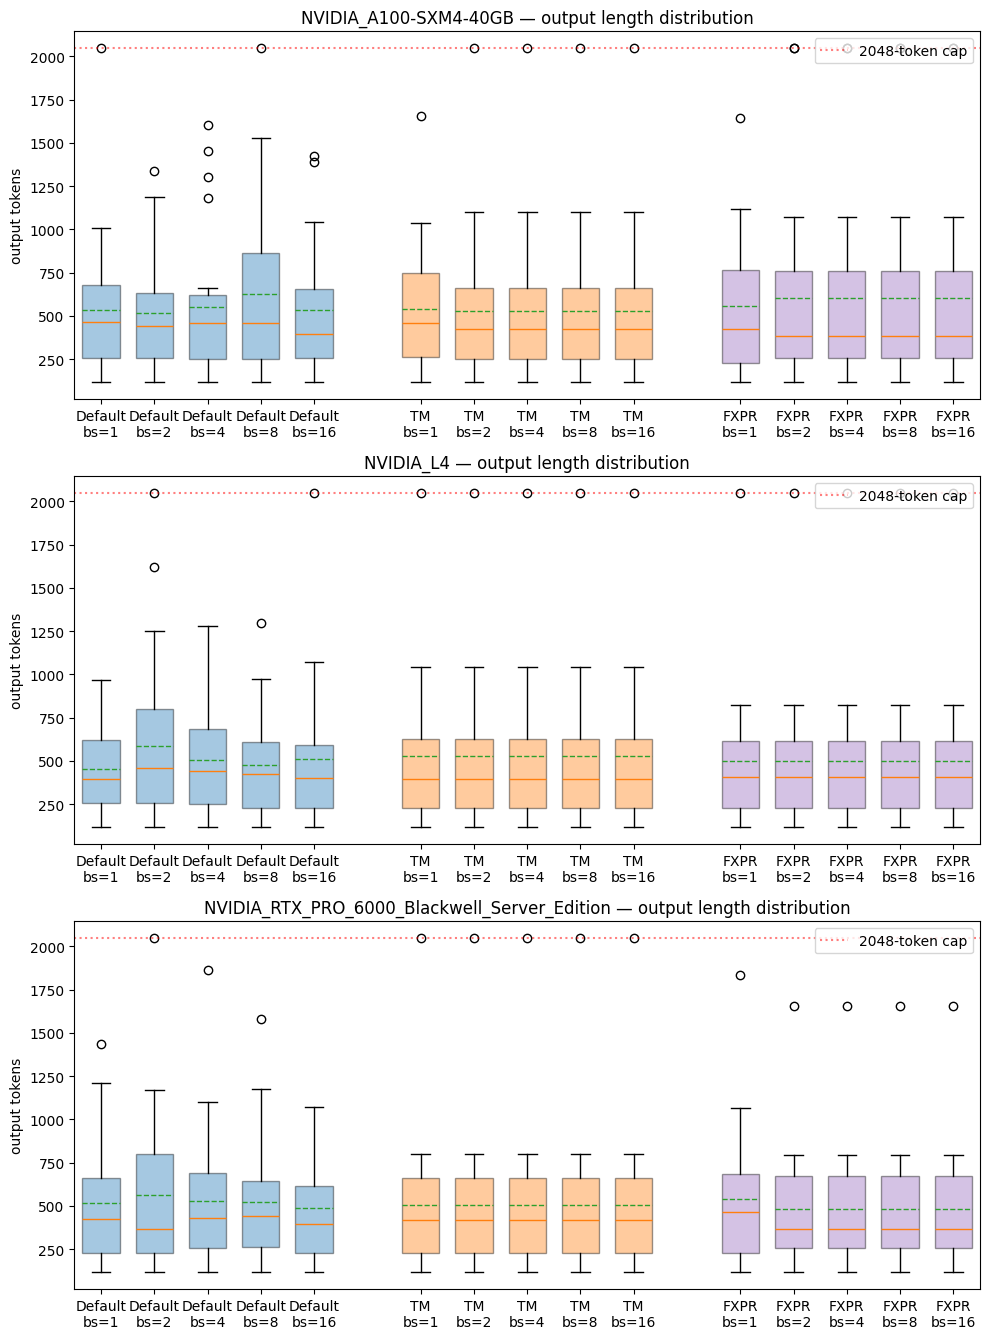

In [2]:
fig, axes = plt.subplots(len(GPUS), 1, figsize=(10, 4.5 * len(GPUS)), squeeze=False)
for gi, gpu in enumerate(GPUS):
    ax = axes[gi, 0]
    g = df[df['gpu'] == gpu]
    data, positions, labels, colors = [], [], [], []
    for ei, eng in enumerate(ENGINES):
        for bi, bs in enumerate(BS):
            sub = g[(g['engine_label'] == eng) & (g['batch_size'] == bs)]
            data.append(sub['n_output_tokens'].values)
            positions.append(ei * (len(BS) + 1) + bi)
            labels.append(f'{eng}\nbs={bs}')
            colors.append(palette[eng])

    bp = ax.boxplot(data, positions=positions, widths=0.7, patch_artist=True,
                    showmeans=True, meanline=True)
    for patch, c in zip(bp['boxes'], colors):
        patch.set_facecolor(c); patch.set_alpha(0.4)
    ax.set_xticks(positions); ax.set_xticklabels(labels)
    ax.set_ylabel('output tokens')
    ax.axhline(2048, color='red', linestyle=':', alpha=0.5, label='2048-token cap')
    ax.set_title(f'{gpu} — output length distribution')
    ax.legend(loc='upper right')
plt.tight_layout(); plt.show()

## Truncation rate

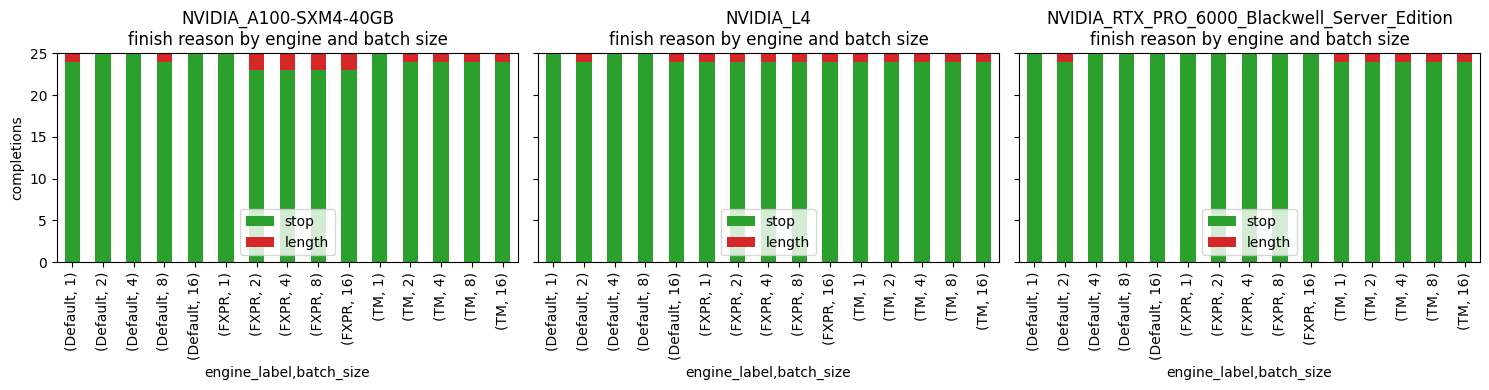

In [3]:
fig, axes = plt.subplots(1, len(GPUS), figsize=(5 * len(GPUS), 4),
                         squeeze=False, sharey=True)
for gi, gpu in enumerate(GPUS):
    ax = axes[0, gi]
    g = df[df['gpu'] == gpu]
    counts = g.groupby(['engine_label', 'batch_size', 'finish_reason']).size().unstack(fill_value=0)
    cols = [c for c in ['stop', 'length'] if c in counts.columns]
    counts[cols].plot(kind='bar', stacked=True, ax=ax,
                     color={'stop': '#2ca02c', 'length': '#d62728'})
    ax.set_title(f'{gpu}\nfinish reason by engine and batch size')
    ax.set_ylabel('completions' if gi == 0 else '')
    ax.legend(title='')
plt.tight_layout()
plt.show()

## Token-identity across batch sizes

For each engine and each pair of batch sizes `(a, b)`, the share of problems
where the bs=a completion has *exactly* the same token IDs as the bs=b
completion. The diagonal is 1.0 by definition. Anything off-diagonal below 1.0
is non-invariance.

Below the heatmap: how many of the 500 problems produced identical tokens at
*every* batch size.

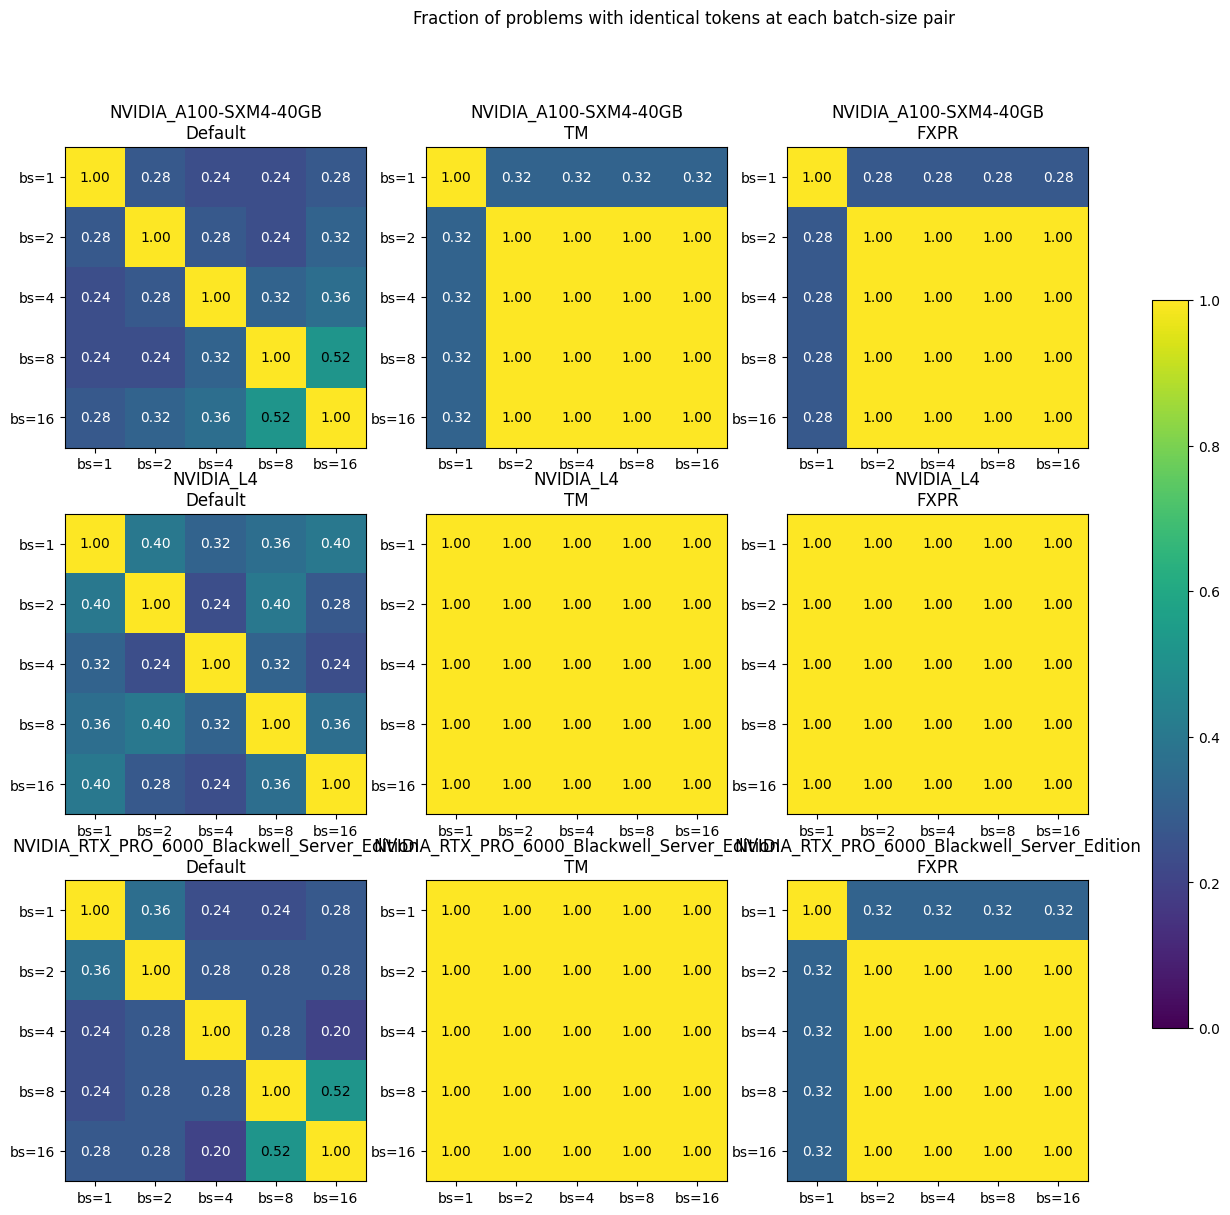

NVIDIA_A100-SXM4-40GB | Default: 4/25 problems identical across all batch sizes
NVIDIA_A100-SXM4-40GB | TM: 8/25 problems identical across all batch sizes
NVIDIA_A100-SXM4-40GB | FXPR: 7/25 problems identical across all batch sizes
NVIDIA_L4 | Default: 4/25 problems identical across all batch sizes
NVIDIA_L4 | TM: 25/25 problems identical across all batch sizes
NVIDIA_L4 | FXPR: 25/25 problems identical across all batch sizes
NVIDIA_RTX_PRO_6000_Blackwell_Server_Edition | Default: 3/25 problems identical across all batch sizes
NVIDIA_RTX_PRO_6000_Blackwell_Server_Edition | TM: 25/25 problems identical across all batch sizes
NVIDIA_RTX_PRO_6000_Blackwell_Server_Edition | FXPR: 8/25 problems identical across all batch sizes


In [4]:
def pairwise_matrix(eng_df):
    pivot = eng_df.groupby(['problem_id', 'batch_size'])['token_ids'].first().unstack('batch_size')
    bss = sorted(pivot.columns.tolist())
    m = np.zeros((len(bss), len(bss)))
    for i, a in enumerate(bss):
        for j, b in enumerate(bss):
            both = pivot[[a, b]].dropna()
            col_a = both.iloc[:, 0].apply(tuple)
            col_b = both.iloc[:, 1].apply(tuple)
            m[i, j] = (col_a == col_b).mean() if len(both) else float('nan')
    return bss, m

fig, axes = plt.subplots(len(GPUS), len(ENGINES),
                         figsize=(5.5 * len(ENGINES), 4.5 * len(GPUS)),
                         squeeze=False)
im = None
for gi, gpu in enumerate(GPUS):
    for ei, eng in enumerate(ENGINES):
        ax = axes[gi, ei]
        sub = df[(df['gpu'] == gpu) & (df['engine_label'] == eng)]
        bss, m = pairwise_matrix(sub)
        im = ax.imshow(m, vmin=0, vmax=1, cmap='viridis')
        ax.set_xticks(range(len(bss))); ax.set_xticklabels([f'bs={b}' for b in bss])
        ax.set_yticks(range(len(bss))); ax.set_yticklabels([f'bs={b}' for b in bss])
        for i in range(len(bss)):
            for j in range(len(bss)):
                ax.text(j, i, f'{m[i, j]:.2f}', ha='center', va='center',
                        color='white' if m[i, j] < 0.5 else 'black')
        ax.set_title(f'{gpu}\n{eng}')
fig.suptitle('Fraction of problems with identical tokens at each batch-size pair')
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.7)
plt.show()

for gpu in GPUS:
    for eng in ENGINES:
        pivot = (df[(df['gpu'] == gpu) & (df['engine_label'] == eng)]
                 .groupby(['problem_id', 'batch_size'])['token_ids'].first().unstack('batch_size'))
        if pivot.empty:
            continue
        full = pivot.dropna().apply(lambda r: len({tuple(x) for x in r}) == 1, axis=1)
        print(f'{gpu} | {eng}: {int(full.sum())}/{len(full)} problems identical across all batch sizes')

### Per-engine view: identity across (GPU, batch size)

One heatmap per engine. Rows and columns enumerate every `(GPU, batch_size)`
combination, and each cell is the fraction of problems whose token IDs match
between those two runs. Within-GPU blocks (along the diagonal) reproduce the
earlier batch-size matrix; off-diagonal blocks answer the cross-GPU question
*"does this engine give the same output on a different GPU?"*.

Red lines separate the GPU blocks.


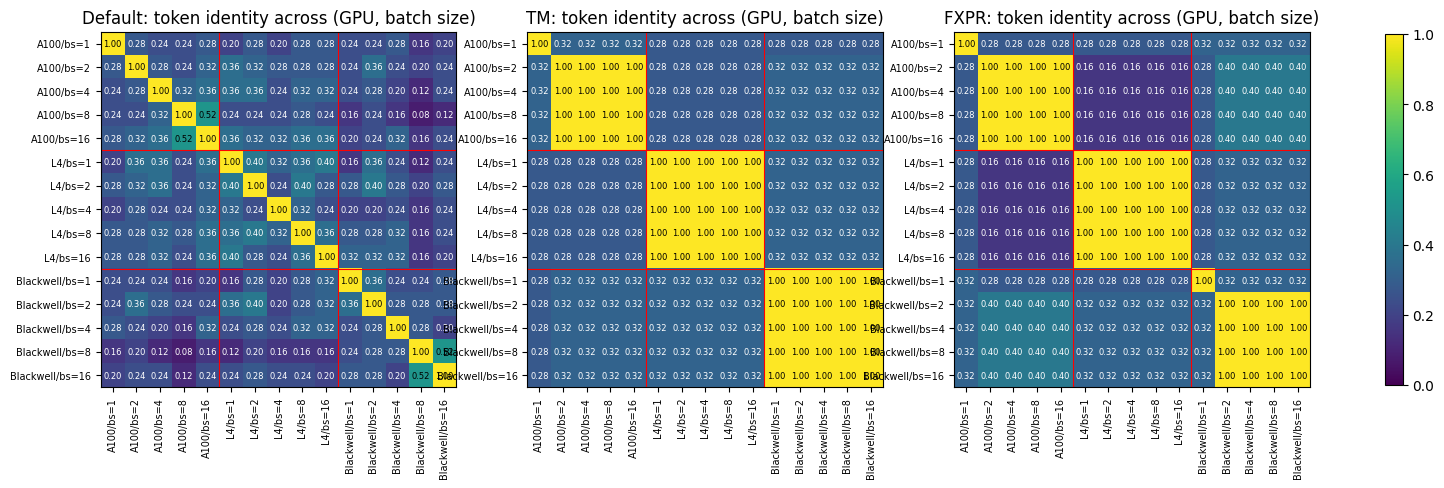

Fraction of problems with identical tokens across ALL (GPU, batch size) combinations:
   Default: 2/25
        TM: 5/25
      FXPR: 4/25


In [5]:
def _gpu_short(g):
    if 'A100' in g: return 'A100'
    if 'L4' in g: return 'L4'
    if 'Blackwell' in g: return 'Blackwell'
    return g

def gpu_bs_identity(eng_df):
    # multi-index columns: (gpu, batch_size); one row per problem_id
    pivot = (eng_df
             .groupby(['problem_id', 'gpu', 'batch_size'])['token_ids']
             .first()
             .unstack(['gpu', 'batch_size']))
    # order columns: GPU outer, batch size inner
    cols = sorted(pivot.columns.tolist(), key=lambda gb: (GPUS.index(gb[0]), BS.index(gb[1])))
    pivot = pivot[cols]
    n = len(cols)
    m = np.full((n, n), np.nan)
    for i, a in enumerate(cols):
        for j, b in enumerate(cols):
            both = pivot[[a, b]].dropna()
            if not len(both):
                continue
            col_a = both.iloc[:, 0].apply(tuple)
            col_b = both.iloc[:, 1].apply(tuple)
            m[i, j] = (col_a == col_b).mean()
    return cols, m

fig, axes = plt.subplots(1, len(ENGINES),
                         figsize=(6.5 * len(ENGINES), 6.5), squeeze=False)
im = None
for ei, eng in enumerate(ENGINES):
    ax = axes[0, ei]
    sub = df[df['engine_label'] == eng]
    cols, m = gpu_bs_identity(sub)
    im = ax.imshow(m, vmin=0, vmax=1, cmap='viridis')
    labels = [f'{_gpu_short(g)}/bs={b}' for (g, b) in cols]
    ax.set_xticks(range(len(cols))); ax.set_xticklabels(labels, rotation=90, fontsize=7)
    ax.set_yticks(range(len(cols))); ax.set_yticklabels(labels, fontsize=7)
    for i in range(len(cols)):
        for j in range(len(cols)):
            v = m[i, j]
            if np.isfinite(v):
                ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=6,
                        color='white' if v < 0.5 else 'black')
    # GPU block separators
    for k in range(1, len(GPUS)):
        ax.axvline(k * len(BS) - 0.5, color='red', lw=0.8)
        ax.axhline(k * len(BS) - 0.5, color='red', lw=0.8)
    ax.set_title(f'{eng}: token identity across (GPU, batch size)')
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.7)
plt.show()

# Per-engine summary: across all (GPU, bs) — 3 GPUs * len(BS) runs — how often
# do all 15 runs agree per problem?
print('Fraction of problems with identical tokens across ALL (GPU, batch size) combinations:')
for eng in ENGINES:
    sub = df[df['engine_label'] == eng]
    pivot = (sub.groupby(['problem_id', 'gpu', 'batch_size'])['token_ids']
                .first().unstack(['gpu', 'batch_size']))
    if pivot.empty:
        continue
    full = pivot.dropna().apply(lambda r: len({tuple(x) for x in r}) == 1, axis=1)
    print(f'  {eng:>8}: {int(full.sum())}/{len(full)}')


## Per-problem length stability

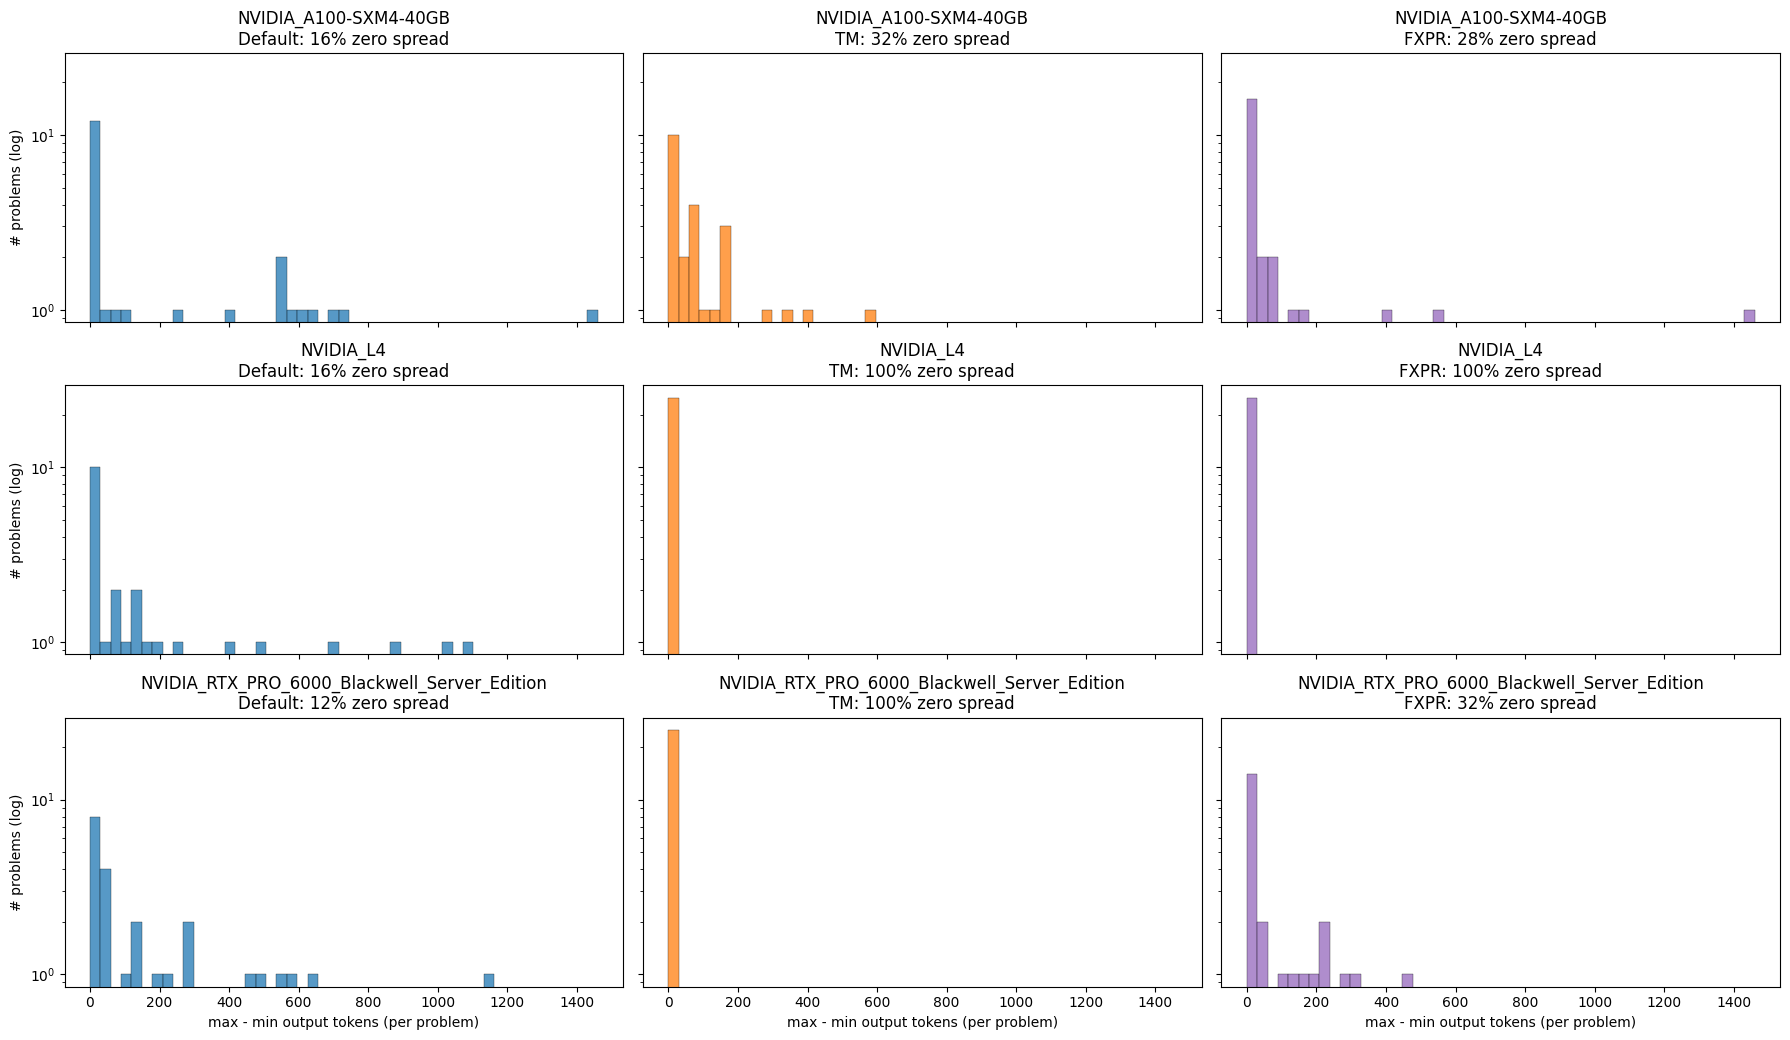

In [6]:
spread = df.groupby(['gpu', 'engine_label', 'problem_id'])['n_output_tokens'].agg(['min', 'max'])
spread['range'] = spread['max'] - spread['min']

fig, axes = plt.subplots(len(GPUS), len(ENGINES),
                         figsize=(6 * len(ENGINES), 3.5 * len(GPUS)),
                         sharey=True, sharex=True, squeeze=False)
bins = np.linspace(0, max(1, spread['range'].max()) + 1, 50)
for gi, gpu in enumerate(GPUS):
    for ei, eng in enumerate(ENGINES):
        ax = axes[gi, ei]
        try:
            vals = spread.xs((gpu, eng), level=('gpu', 'engine_label'))['range']
        except KeyError:
            vals = pd.Series([], dtype=float)
        ax.hist(vals, bins=bins, color=palette[eng], alpha=0.75,
                edgecolor='black', linewidth=0.3)
        ax.set_yscale('log')
        if gi == len(GPUS) - 1:
            ax.set_xlabel('max - min output tokens (per problem)')
        pct_zero = (vals == 0).mean() * 100 if len(vals) else 0
        ax.set_title(f'{gpu}\n{eng}: {pct_zero:.0f}% zero spread')
        if ei == 0:
            ax.set_ylabel('# problems (log)')
plt.tight_layout(); plt.show()

## Cross-batch identity by layer

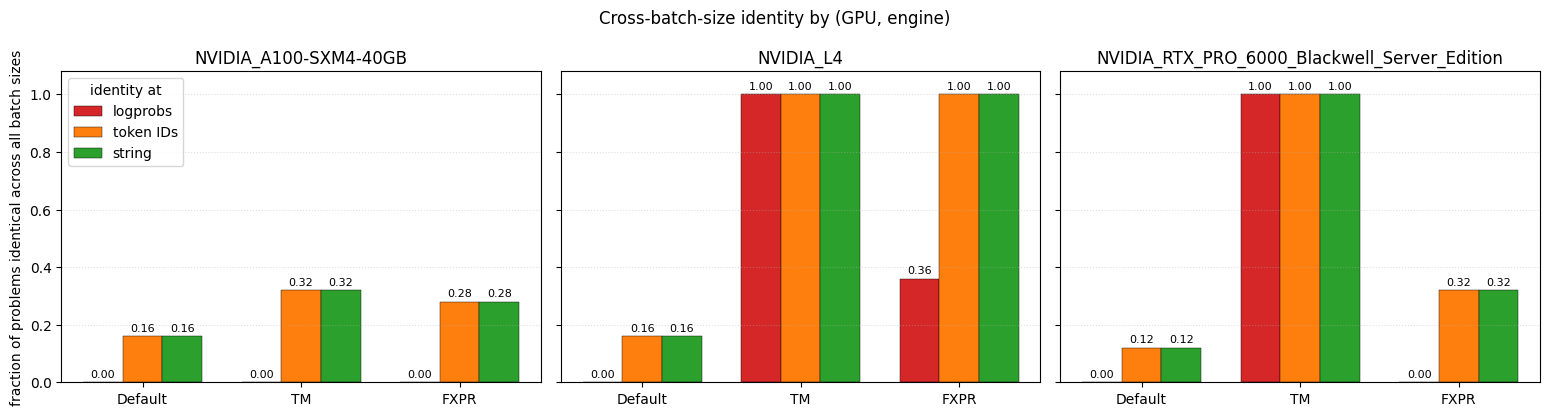

                                         gpu  engine  n_problems  logprobs  tokens  text
                       NVIDIA_A100-SXM4-40GB Default          25      0.00    0.16  0.16
                       NVIDIA_A100-SXM4-40GB      TM          25      0.00    0.32  0.32
                       NVIDIA_A100-SXM4-40GB    FXPR          25      0.00    0.28  0.28
                                   NVIDIA_L4 Default          25      0.00    0.16  0.16
                                   NVIDIA_L4      TM          25      1.00    1.00  1.00
                                   NVIDIA_L4    FXPR          25      0.36    1.00  1.00
NVIDIA_RTX_PRO_6000_Blackwell_Server_Edition Default          25      0.00    0.12  0.12
NVIDIA_RTX_PRO_6000_Blackwell_Server_Edition      TM          25      1.00    1.00  1.00
NVIDIA_RTX_PRO_6000_Blackwell_Server_Edition    FXPR          25      0.00    0.32  0.32


In [7]:
def _all_equal(series):
    vals = list(series)
    first = vals[0]
    return all(v == first for v in vals[1:])

work = df.copy()
work['logprobs'] = work['output_logprobs'].map(json.loads).map(tuple)
work['tokens'] = work['token_ids'].map(tuple)
work['text'] = work['completion_text'].fillna('')

rows = []
for (gpu, eng), g in work.groupby(['gpu', 'engine_label']):
    per_problem = g.groupby('problem_id').agg({
        'logprobs': _all_equal,
        'tokens': _all_equal,
        'text': _all_equal,
        'batch_size': 'nunique',
    })
    per_problem = per_problem[per_problem['batch_size'] == len(BS)]
    n = len(per_problem)
    if n == 0:
        continue
    rows.append({
        'gpu': gpu,
        'engine': eng,
        'n_problems': n,
        'logprobs': per_problem['logprobs'].mean(),
        'tokens': per_problem['tokens'].mean(),
        'text': per_problem['text'].mean(),
    })

ident = pd.DataFrame(rows)
ident['engine_order'] = ident['engine'].map(ENGINE_ORDER).fillna(99)
ident = ident.sort_values(['gpu', 'engine_order']).drop(columns='engine_order').reset_index(drop=True)

metrics = [('logprobs', 'logprobs'), ('tokens', 'token IDs'), ('text', 'string')]
metric_colors = {'logprobs': '#d62728', 'tokens': '#ff7f0e', 'text': '#2ca02c'}

fig, axes = plt.subplots(1, len(GPUS), figsize=(5.2 * len(GPUS), 4.2),
                         sharey=True, squeeze=False)
bar_w = 0.25
for gi, gpu in enumerate(GPUS):
    ax = axes[0, gi]
    sub = ident[ident['gpu'] == gpu]
    x = np.arange(len(sub))
    for mi, (col, label) in enumerate(metrics):
        offset = (mi - 1) * bar_w
        vals = sub[col].values
        bars = ax.bar(x + offset, vals, bar_w, color=metric_colors[col],
                      label=label, edgecolor='black', linewidth=0.3)
        for rect, v in zip(bars, vals):
            ax.text(rect.get_x() + rect.get_width() / 2, v + 0.01,
                    f'{v:.2f}', ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(sub['engine'].tolist())
    ax.set_ylim(0, 1.08)
    ax.set_title(gpu)
    if gi == 0:
        ax.set_ylabel('fraction of problems identical across all batch sizes')
    ax.grid(axis='y', linestyle=':', alpha=0.4)
axes[0, 0].legend(title='identity at', loc='upper left')
fig.suptitle('Cross-batch-size identity by (GPU, engine)')
plt.tight_layout()
plt.show()

print(ident.to_string(index=False))

## MATH-500 accuracy by configuration

Extracts the predicted answer from the last `\boxed{...}` in `completion_text`,
joins against HuggingFaceH4/MATH-500 on `problem_id`, and reports accuracy per
(GPU, engine, batch size). If `math_verify` is installed it is used for symbolic
equivalence; otherwise a Minerva-style string normalizer is the fallback.


In [8]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve() / 'src'))
from batch_invariance_bench.score import score_dir, accuracy_table

scored = score_dir(DATA)
print(f'scored {len(scored)} rows | overall accuracy = {scored["correct"].mean():.3f}')
print(f'extraction failures (no boxed answer): {scored["pred"].isna().sum()}')

acc = accuracy_table(scored, by=('gpu', 'engine_label', 'batch_size'))
print()
print(acc.to_string(index=False))


/home/gursukh/Workspace/Benchmarking-Batch-Invariance-In-LLM/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


scored 1125 rows | overall accuracy = 0.520
extraction failures (no boxed answer): 27

                                         gpu engine_label  batch_size  n  correct  accuracy
                       NVIDIA_A100-SXM4-40GB      Default           1 25       13      0.52
                       NVIDIA_A100-SXM4-40GB      Default           2 25       11      0.44
                       NVIDIA_A100-SXM4-40GB      Default           4 25       10      0.40
                       NVIDIA_A100-SXM4-40GB      Default           8 25       11      0.44
                       NVIDIA_A100-SXM4-40GB      Default          16 25       11      0.44
                       NVIDIA_A100-SXM4-40GB         FXPR           1 25       12      0.48
                       NVIDIA_A100-SXM4-40GB         FXPR           2 25       13      0.52
                       NVIDIA_A100-SXM4-40GB         FXPR           4 25       13      0.52
                       NVIDIA_A100-SXM4-40GB         FXPR           8 25       13    

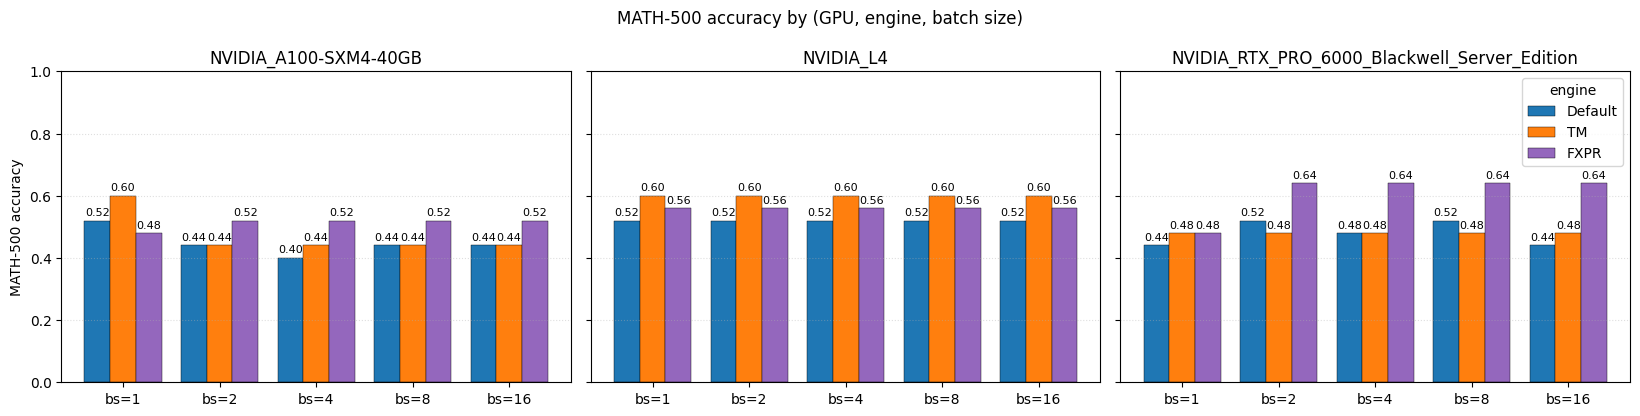

In [9]:
# Grouped bar chart: accuracy per (engine, batch_size) for each GPU.
fig, axes = plt.subplots(1, len(GPUS), figsize=(5.5 * len(GPUS), 4.2),
                         sharey=True, squeeze=False)
bar_w = 0.8 / max(1, len(ENGINES))
x = np.arange(len(BS))
for gi, gpu in enumerate(GPUS):
    ax = axes[0, gi]
    g = acc[acc['gpu'] == gpu]
    for ei, eng in enumerate(ENGINES):
        sub = g[g['engine_label'] == eng].set_index('batch_size').reindex(BS)
        offset = (ei - (len(ENGINES) - 1) / 2) * bar_w
        bars = ax.bar(x + offset, sub['accuracy'].values, bar_w,
                      color=palette[eng], label=eng,
                      edgecolor='black', linewidth=0.3)
        for rect, v in zip(bars, sub['accuracy'].values):
            if np.isfinite(v):
                ax.text(rect.get_x() + rect.get_width() / 2, v + 0.01,
                        f'{v:.2f}', ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels([f'bs={b}' for b in BS])
    ax.set_ylim(0, 1.0)
    ax.set_title(gpu)
    ax.grid(axis='y', linestyle=':', alpha=0.4)
    if gi == 0:
        ax.set_ylabel('MATH-500 accuracy')
    if gi == len(GPUS) - 1:
        ax.legend(title='engine', loc='upper right')
fig.suptitle('MATH-500 accuracy by (GPU, engine, batch size)')
plt.tight_layout()
plt.show()


                                         gpu engine_label   n  correct  accuracy
                       NVIDIA_A100-SXM4-40GB      Default 125       56     0.448
                       NVIDIA_A100-SXM4-40GB           TM 125       59     0.472
                       NVIDIA_A100-SXM4-40GB         FXPR 125       64     0.512
                                   NVIDIA_L4      Default 125       65     0.520
                                   NVIDIA_L4           TM 125       75     0.600
                                   NVIDIA_L4         FXPR 125       70     0.560
NVIDIA_RTX_PRO_6000_Blackwell_Server_Edition      Default 125       60     0.480
NVIDIA_RTX_PRO_6000_Blackwell_Server_Edition           TM 125       60     0.480
NVIDIA_RTX_PRO_6000_Blackwell_Server_Edition         FXPR 125       76     0.608


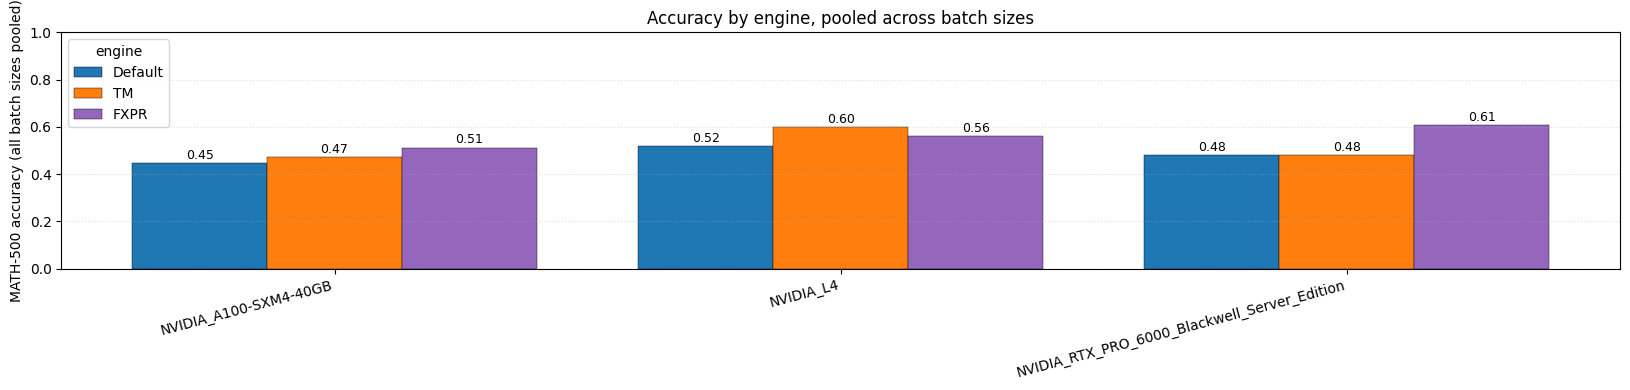

In [10]:
# Per-(GPU, engine) accuracy collapsed across batch sizes.
collapsed = accuracy_table(scored, by=('gpu', 'engine_label'))
collapsed['engine_order'] = collapsed['engine_label'].map(ENGINE_ORDER).fillna(99)
collapsed = collapsed.sort_values(['gpu', 'engine_order']).drop(columns='engine_order')
print(collapsed.to_string(index=False))

fig, ax = plt.subplots(figsize=(1.6 * len(GPUS) * len(ENGINES) + 2, 4))
positions = np.arange(len(GPUS))
bar_w = 0.8 / max(1, len(ENGINES))
for ei, eng in enumerate(ENGINES):
    vals = [collapsed[(collapsed['gpu'] == g) & (collapsed['engine_label'] == eng)]['accuracy'].iloc[0]
            if not collapsed[(collapsed['gpu'] == g) & (collapsed['engine_label'] == eng)].empty else np.nan
            for g in GPUS]
    offset = (ei - (len(ENGINES) - 1) / 2) * bar_w
    bars = ax.bar(positions + offset, vals, bar_w, color=palette[eng],
                  label=eng, edgecolor='black', linewidth=0.3)
    for rect, v in zip(bars, vals):
        if np.isfinite(v):
            ax.text(rect.get_x() + rect.get_width() / 2, v + 0.005,
                    f'{v:.2f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(positions)
ax.set_xticklabels(GPUS, rotation=15, ha='right')
ax.set_ylabel('MATH-500 accuracy (all batch sizes pooled)')
ax.set_ylim(0, 1.0)
ax.legend(title='engine')
ax.grid(axis='y', linestyle=':', alpha=0.4)
ax.set_title('Accuracy by engine, pooled across batch sizes')
plt.tight_layout()
plt.show()
